# SmartReview AI - Week 2
## Problem Definition, Dataset Analysis & EDA

## 1. Problem Statement

The SmartReview AI system aims to extract meaningful insights from customer reviews and assist users in making informed decisions.

The system is designed to solve the following four key sub-problems:

1. Sentiment Analysis:
   Classify reviews into positive or negative categories based on textual content.

2. Helpfulness Prediction:
   Predict how useful a review will be to other users based on its content and metadata.

3. Fake Review Detection:
   Identify suspicious or low-quality reviews that may not be genuine.

4. Review Summarization:
   Generate concise summaries of long reviews to improve readability and user experience.

## 2. Dataset Loading

In [31]:
# ================================
# 📦 1. Import Libraries
# ================================
import pandas as pd

print("📂 Loading dataset...")

# ================================
# 📊 2. Load Dataset (Robust Way)
# ================================
df = pd.read_csv(
    "Reviews.csv",
    engine='python',        # Handles complex CSV better
    sep=',',
    quotechar='"',
    escapechar='\\',        # Handles escaped quotes properly
    encoding='utf-8',
    on_bad_lines='warn'     # Skip problematic rows but show warning
)

# ================================
# 📈 3. Basic Info
# ================================
print("\n✅ Dataset Loaded Successfully!")
print("📊 Rows loaded:", len(df))
print("📊 Columns:", df.shape[1])

# ================================
# 🔍 4. Preview Data
# ================================
df.head()

📂 Loading dataset...


/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 35360: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 45904: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 74274: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 83657: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 88617: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 95298: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 181206: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserWarning: Skipping line 182992: ',' expected after '"'

  df = pd.read_csv(
/tmp/ipykernel_38754/2623540121.py:11: ParserW


✅ Dataset Loaded Successfully!
📊 Rows loaded: 568415
📊 Columns: 10


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [32]:
# ================================
# 5. Compare with Original Size
# ================================
original_rows = 568454
loaded_rows = len(df)

print("\n📌 Data Summary:")
print("Original rows:", original_rows)
print("Loaded rows:", loaded_rows)
print("Rows removed:", original_rows - loaded_rows)
print("Data retained (%):", round((loaded_rows / original_rows) * 100, 2))


📌 Data Summary:
Original rows: 568454
Loaded rows: 568415
Rows removed: 39
Data retained (%): 99.99


In [33]:
df_original = df.copy()

## 3. Data Understanding

In [34]:
import pandas as pd

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Shape
rows, cols = df.shape
print(f"\n Total Rows    : {rows}")
print(f"\n Total Columns : {cols}")

print("\n" + "="*60)
print("COLUMN DETAILS")
print("="*60)

# Column info table
column_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(column_info)

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)

display(df.describe())

print("\n" + "="*60)
print("RATING DISTRIBUTION")
print("="*60)

display(df['Score'].value_counts().sort_index())

DATASET OVERVIEW

 Total Rows    : 568415

 Total Columns : 10

COLUMN DETAILS


,Column Name,Data Type,Missing Values,Unique Values
0,Id,int64,0,568415
1,ProductId,object,0,74256
2,UserId,object,0,256045
3,ProfileName,object,26,218404
4,HelpfulnessNumerator,int64,0,231
5,HelpfulnessDenominator,int64,0,234
6,Score,int64,0,5
7,Time,int64,0,3168
8,Summary,object,27,295722
9,Text,object,0,393551



NUMERICAL SUMMARY


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568415.000000,568415.000000,568415.000000,568415.000000,5.684150e+05
mean,284232.668313,1.743888,2.228872,4.183252,1.296255e+09
std,164098.807297,7.636762,8.290003,1.310401,4.804420e+07
min,1.000000,0.000000,0.000000,1.000000,9.393408e+08
25%,142120.500000,0.000000,0.000000,4.000000,1.271290e+09
50%,284236.000000,0.000000,1.000000,5.000000,1.311120e+09
75%,426345.500000,2.000000,2.000000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.000000,5.000000,1.351210e+09



RATING DISTRIBUTION


,count
Score,
1,52262
2,29760
3,42637
4,80650
5,363106


/tmp/ipykernel_38754/985890946.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


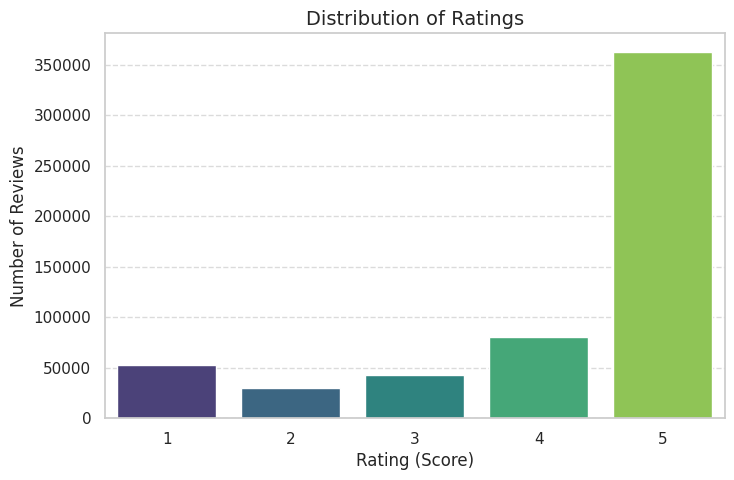

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='Score', data=df, palette='viridis')

plt.title("Distribution of Ratings", fontsize=14)
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4. Data Cleaning

In [36]:
df = df_original.copy()
print("Reset dataset:", df.shape)

Reset dataset: (568415, 10)


In [37]:
import pandas as pd

print("\n🧹 DATA CLEANING")

# Initial shape
print("Initial Shape:", df.shape)

# -----------------------------
# Handle Missing Values
# -----------------------------
df['Text'] = df['Text'].fillna("")
df['Summary'] = df['Summary'].fillna("No Summary")
df['ProfileName'] = df['ProfileName'].fillna("Unknown")

# -----------------------------
# Feature Engineering
# -----------------------------
df['review_length'] = df['Text'].apply(len)
df['helpful_votes'] = df['HelpfulnessNumerator']
df['helpfulness_ratio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1)

print("Features created: review_length, helpful_votes, helpfulness_ratio")

# -----------------------------
# Final Missing Check
# -----------------------------
missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nRemaining Missing Values:")
print(missing if len(missing) > 0 else "No missing values")

# Final shape
print("\nFinal Shape:", df.shape)

# Sample check
print("\nSample Data:")
display(df[['review_length','helpful_votes','helpfulness_ratio']].head())


🧹 DATA CLEANING
Initial Shape: (568415, 10)
Features created: review_length, helpful_votes, helpfulness_ratio

Remaining Missing Values:
No missing values

Final Shape: (568415, 13)

Sample Data:


,review_length,helpful_votes,helpfulness_ratio
0,263,1,0.50
1,190,0,0.00
2,509,1,0.50
3,219,3,0.75
4,140,0,0.00


## 5. Exploratory Data Analysis (EDA)


EXPLORATORY DATA ANALYSIS


/tmp/ipykernel_38754/349480630.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


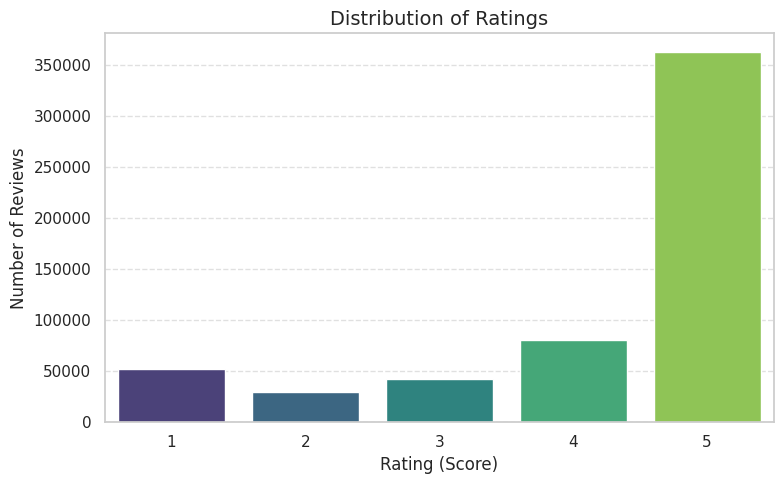

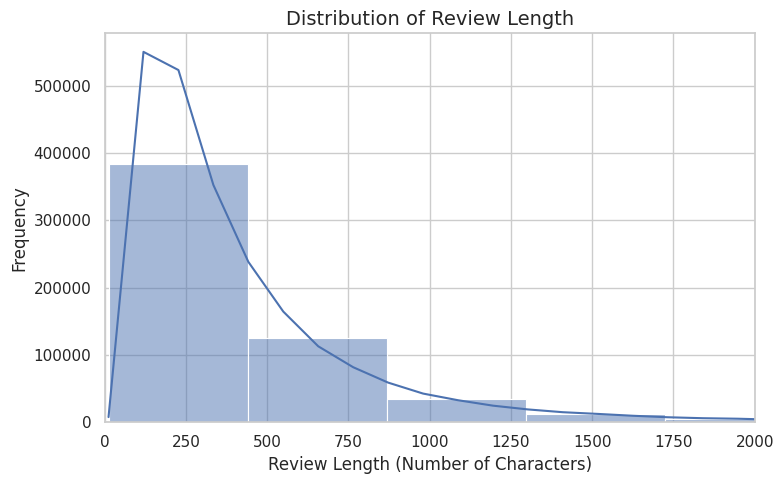

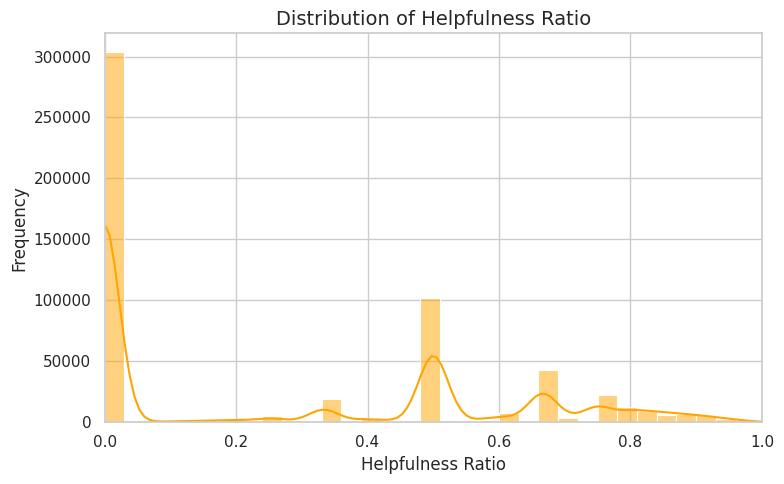

/tmp/ipykernel_38754/349480630.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='review_length', data=df,


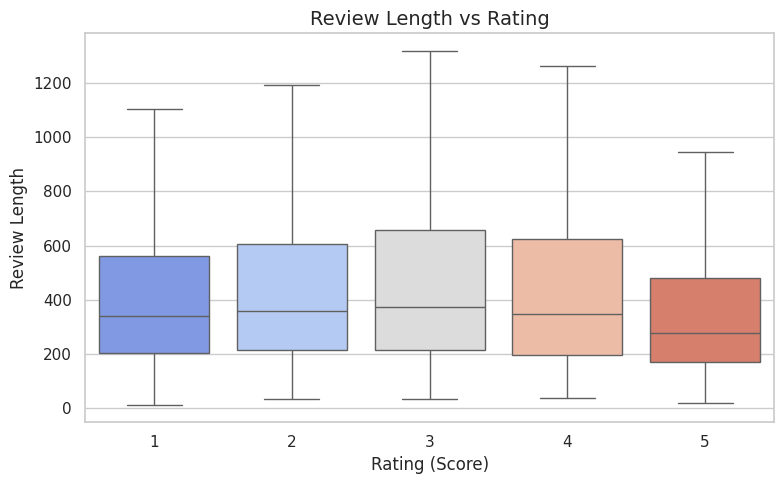

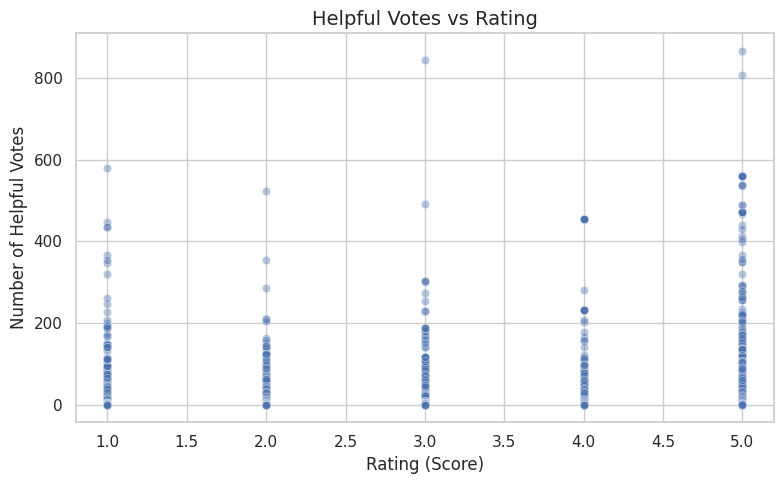

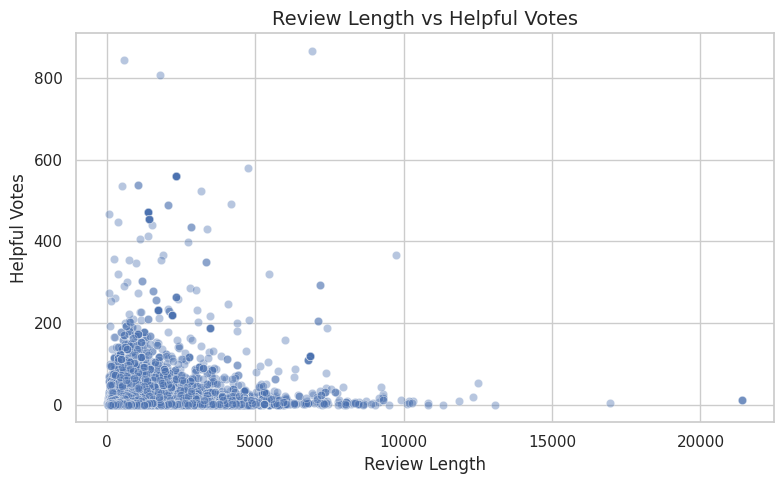

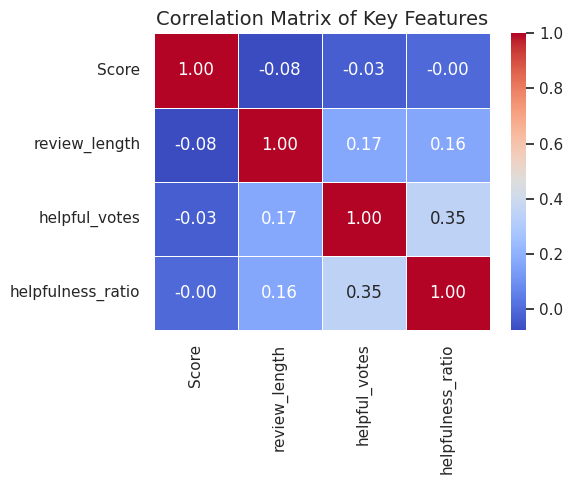

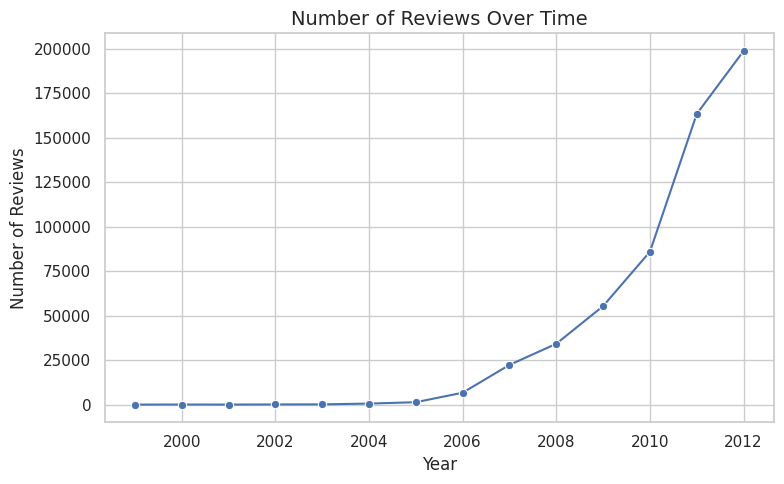

/tmp/ipykernel_38754/349480630.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.values,


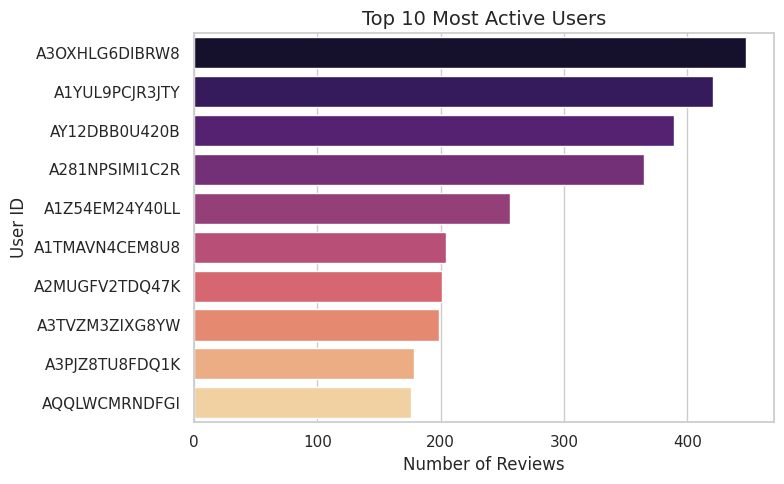

In [42]:
# ============================================================
# 📊 EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 🎨 Visualization Settings (Professional Theme)
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)


# ============================================================
# 1️⃣ DISTRIBUTION OF RATINGS
# ============================================================
plt.figure()
sns.countplot(x='Score', data=df, palette='viridis')

plt.title("Distribution of Ratings")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ============================================================
# 2️⃣ DISTRIBUTION OF REVIEW LENGTH
# ============================================================
plt.figure()
sns.histplot(df['review_length'], bins=50, kde=True)

plt.xlim(0, 2000)  # Remove extreme outliers for clarity
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 3️⃣ DISTRIBUTION OF HELPFULNESS RATIO
# ============================================================
plt.figure()
sns.histplot(df['helpfulness_ratio'], bins=50, kde=True, color='orange')

plt.xlim(0, 1)
plt.title("Distribution of Helpfulness Ratio")
plt.xlabel("Helpfulness Ratio")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 4️⃣ REVIEW LENGTH VS RATING
# ============================================================
plt.figure()
sns.boxplot(x='Score', y='review_length', data=df,
            showfliers=False, palette='coolwarm')

plt.title("Review Length vs Rating")
plt.xlabel("Rating (Score)")
plt.ylabel("Review Length")

plt.tight_layout()
plt.show()


# ============================================================
# 5️⃣ HELPFUL VOTES VS RATING
# ============================================================
plt.figure()
sns.scatterplot(x='Score', y='helpful_votes',
                data=df, alpha=0.4)

plt.title("Helpful Votes vs Rating")
plt.xlabel("Rating (Score)")
plt.ylabel("Number of Helpful Votes")

plt.tight_layout()
plt.show()


# ============================================================
# 6️⃣ REVIEW LENGTH VS HELPFUL VOTES
# ============================================================
plt.figure()
sns.scatterplot(x='review_length', y='helpful_votes',
                data=df, alpha=0.4)

plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")

plt.tight_layout()
plt.show()


# ============================================================
# 7️⃣ CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(6,5))

corr = df[['Score', 'review_length',
           'helpful_votes', 'helpfulness_ratio']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    linecolor='white'
)

plt.title("Correlation Matrix of Key Features")

plt.tight_layout()
plt.show()


# ============================================================
# 8️⃣ TIME-BASED TREND OF REVIEWS (IMPORTANT)
# ============================================================
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year

reviews_per_year = df['Year'].value_counts().sort_index()

plt.figure()
sns.lineplot(x=reviews_per_year.index,
             y=reviews_per_year.values,
             marker='o')

plt.title("Number of Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 9️⃣ TOP 10 MOST ACTIVE USERS
# ============================================================
top_users = df['UserId'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_users.values,
            y=top_users.index,
            palette='magma')

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Reviews")
plt.ylabel("User ID")

plt.tight_layout()
plt.show()

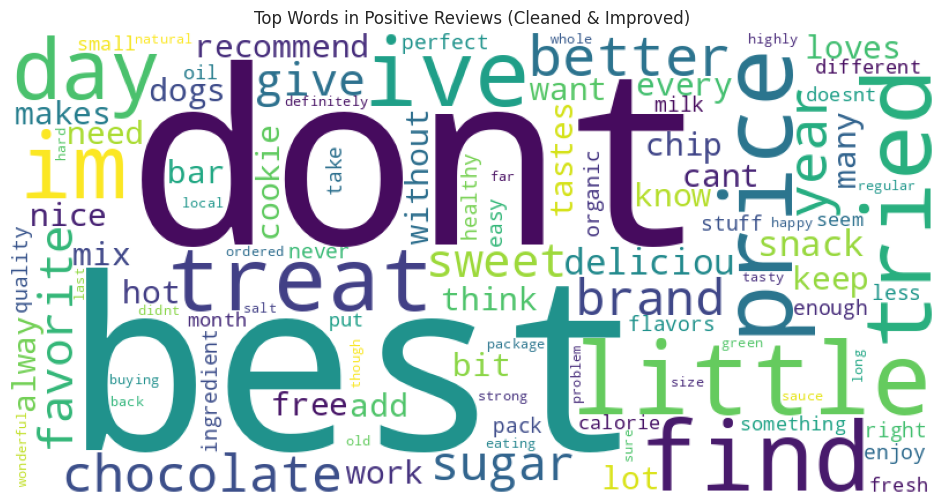

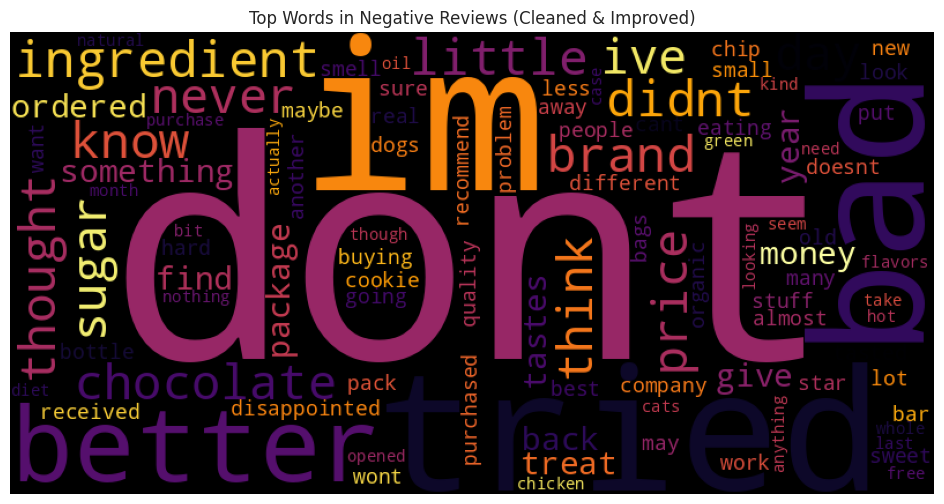

In [38]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re

# ================================
# 🧠 1. Advanced Stopwords
# ================================
stopwords = set(STOPWORDS)

custom_words = [
    'br','one','will','use','amazon','product','food','item',
    'buy','bought','order','taste','love','great','good','really',
    'get','make','time','try','even','also','still','much',
    'first','well','used','using','found','now','got','way',
    'thing','things','go','see','say','said','came','come',

    # REMOVE DOMAIN WORDS
    'coffee','tea','cup','drink','eat','flavor','taste','made',
    'box','bag','product','food','water','dog','cat','store',

    # REMOVE GENERIC ANALYSIS NOISE
    'review','reviews','product','products','one','two','three'
]

stopwords.update(custom_words)

# ================================
# 🧹 2. Text Cleaning Function
# ================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation & numbers
    return text

# Apply cleaning
df['clean_text'] = df['Text'].astype(str).apply(clean_text)

# ================================
# 📊 3. Prepare Text
# ================================
positive_text = " ".join(df[df['Score'] >= 4]['clean_text'])
negative_text = " ".join(df[df['Score'] <= 2]['clean_text'])

# ================================
# 🌟 4. Positive WordCloud
# ================================
plt.figure(figsize=(12,6))

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    colormap='viridis',
    collocations=False,
    max_words=100
).generate(positive_text)

plt.imshow(wc_pos)
plt.axis('off')
plt.title("Top Words in Positive Reviews (Cleaned & Improved)")
plt.show()

# ================================
# 🔥 5. Negative WordCloud
# ================================
plt.figure(figsize=(12,6))

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color='black',
    stopwords=stopwords,
    colormap='inferno',
    collocations=False,
    max_words=100
).generate(negative_text)

plt.imshow(wc_neg)
plt.axis('off')
plt.title("Top Words in Negative Reviews (Cleaned & Improved)")
plt.show()

Positive reviews focus on quality, taste, and satisfaction.
Negative reviews highlight issues like product quality, packaging, or dissatisfaction.

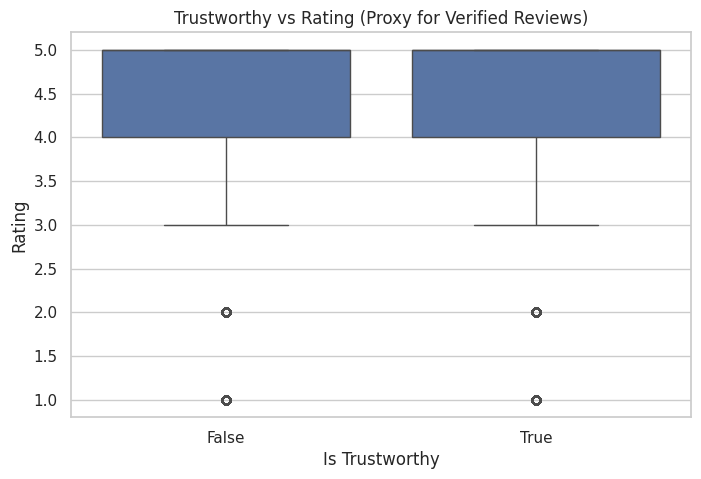

In [41]:
# Create proxy for "verified"
df['is_trustworthy'] = df['helpfulness_ratio'] > 0.5

plt.figure(figsize=(8,5))
sns.boxplot(x='is_trustworthy', y='Score', data=df)

plt.title("Trustworthy vs Rating (Proxy for Verified Reviews)")
plt.xlabel("Is Trustworthy")
plt.ylabel("Rating")

plt.show()

## 6. Key Insights

In [48]:
# Calculate percentages
total_reviews = len(df)

five_star_count = (df['Score'] == 5).sum()
one_star_count = (df['Score'] == 1).sum()

five_star_pct = (five_star_count / total_reviews) * 100
one_star_pct = (one_star_count / total_reviews) * 100

print("📊 Rating Distribution Analysis:")
print(f"Total Reviews      : {total_reviews}")
print(f"5-Star Reviews     : {five_star_count} ({five_star_pct:.2f}%)")
print(f"1-Star Reviews     : {one_star_count} ({one_star_pct:.2f}%)")

📊 Rating Distribution Analysis:
Total Reviews      : 568415
5-Star Reviews     : 363106 (63.88%)
1-Star Reviews     : 52262 (9.19%)



📊 Relationship Between Review Length and Helpfulness:
Correlation (review_length vs helpful_votes): 0.171


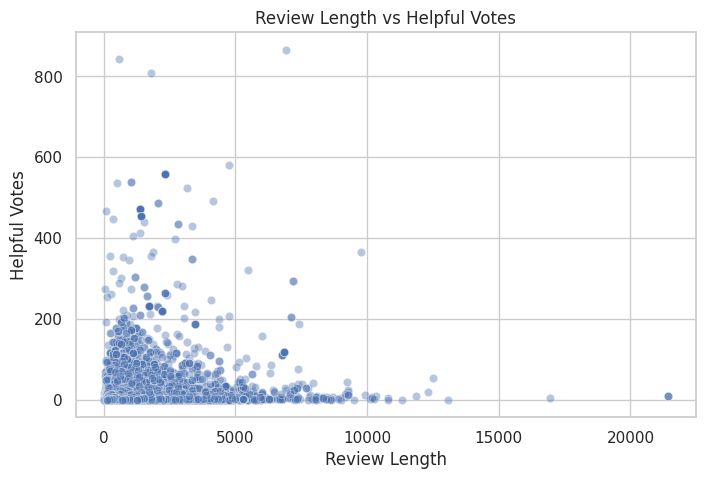

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation value
corr_value = df[['review_length', 'helpful_votes']].corr().iloc[0,1]

print("\n📊 Relationship Between Review Length and Helpfulness:")
print(f"Correlation (review_length vs helpful_votes): {corr_value:.3f}")

# Visualization
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_length', y='helpful_votes', data=df, alpha=0.4)

plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")

plt.show()


📊 Trustworthiness vs Rating:
is_trustworthy
False    4.170534
True     4.228533
Name: Score, dtype: float64


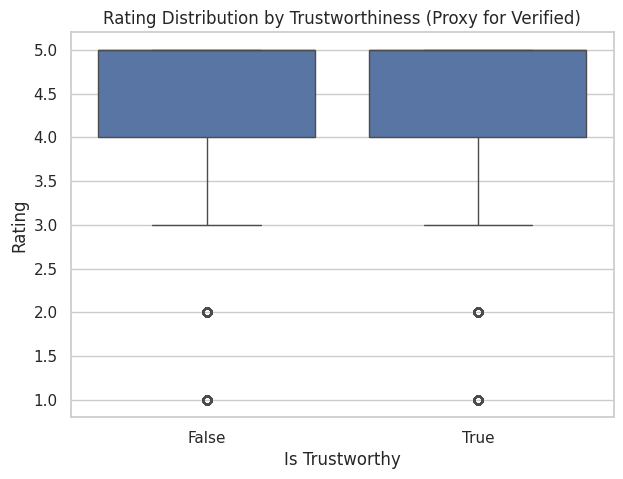

In [50]:
# Create proxy for verified reviews using helpfulness ratio
df['is_trustworthy'] = df['helpfulness_ratio'] > 0.5

# Average rating comparison
trust_rating = df.groupby('is_trustworthy')['Score'].mean()

print("\n📊 Trustworthiness vs Rating:")
print(trust_rating)

# Visualization
plt.figure(figsize=(7,5))
sns.boxplot(x='is_trustworthy', y='Score', data=df)

plt.title("Rating Distribution by Trustworthiness (Proxy for Verified)")
plt.xlabel("Is Trustworthy")
plt.ylabel("Rating")

plt.show()